In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# بارگذاری دیتاست
df = pd.read_csv('USA_cars_datasets.csv')

# حذف ستون‌های بدون استفاده (مانند ایندکس قدیمی، شماره VIN و شماره Lot)
df.drop(['Unnamed: 0', 'vin', 'lot'], axis=1, inplace=True)

# نمایش اطلاعات کلی
print("Data Info:")
print(df.info())

# نمایش ۵ سطر اول
df.head()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         2499 non-null   int64  
 1   brand         2499 non-null   object 
 2   model         2499 non-null   object 
 3   year          2499 non-null   int64  
 4   title_status  2499 non-null   object 
 5   mileage       2499 non-null   float64
 6   color         2499 non-null   object 
 7   state         2499 non-null   object 
 8   country       2499 non-null   object 
 9   condition     2499 non-null   object 
dtypes: float64(1), int64(2), object(7)
memory usage: 195.4+ KB
None


,price,brand,model,year,title_status,mileage,color,state,country,condition
0,6300,toyota,cruiser,2008,clean vehicle,274117.0,black,new jersey,usa,10 days left
1,2899,ford,se,2011,clean vehicle,190552.0,silver,tennessee,usa,6 days left
2,5350,dodge,mpv,2018,clean vehicle,39590.0,silver,georgia,usa,2 days left
3,25000,ford,door,2014,clean vehicle,64146.0,blue,virginia,usa,22 hours left
4,27700,chevrolet,1500,2018,clean vehicle,6654.0,red,florida,usa,22 hours left


In [ ]:
# بررسی و حذف داده‌های تکراری
df.drop_duplicates(inplace=True)

# حذف خودروهایی که قیمت آن‌ها 0 ثبت شده (داده نامعتبر)
df = df[df['price'] > 0]

# بررسی مقادیر گم‌شده
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 price           0
brand           0
model           0
year            0
title_status    0
mileage         0
color           0
state           0
country         0
condition       0
dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# تبدیل متغیرهای متنی به عددی (Encoding)
le = LabelEncoder()
categorical_cols = ['brand', 'model', 'title_status', 'color', 'state', 'country', 'condition']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# نرمال‌سازی داده‌های عددی (Price, Mileage)
scaler = StandardScaler()
df[['price', 'mileage']] = scaler.fit_transform(df[['price', 'mileage']])

print("Preprocessing complete. All features are now numerical and scaled.")
df.head()

Preprocessing complete. All features are now numerical and scaled.


,price,brand,model,year,title_status,mileage,color,state,country,condition
0,-1.069945,27,25,2008,0,4.103166,2,24,1,3
1,-1.354315,8,92,2011,0,2.572485,37,35,1,39
2,-1.149378,7,75,2018,0,-0.192724,37,7,1,16
3,0.493635,8,32,2014,0,0.257075,4,39,1,20
4,0.719392,5,0,2018,0,-0.796021,32,6,1,20


In my view, feature engineering is a must-have when the raw data is in a format that a machine learning model simply cannot interpret, such as categorical text or complex timestamps. For example, a model cannot directly "understand" a car's color or brand name unless we encode them into numbers. It is also essential when the relationship between the features and the target variable is hidden; the model might struggle to find patterns unless we explicitly create ratios or aggregated statistics that highlight those connections.On the other hand, it becomes more of a nice-to-have when you are working with extremely powerful, modern algorithms—like deep learning or certain ensemble methods—that are already capable of capturing non-linear patterns and complex interactions on their own. In such cases, manually creating new features might slightly improve the score, but it isn't strictly necessary to get a functional model. Ultimately, it's a trade-off between the time spent on manual engineering and the marginal gain in accuracy you actually need for the project.

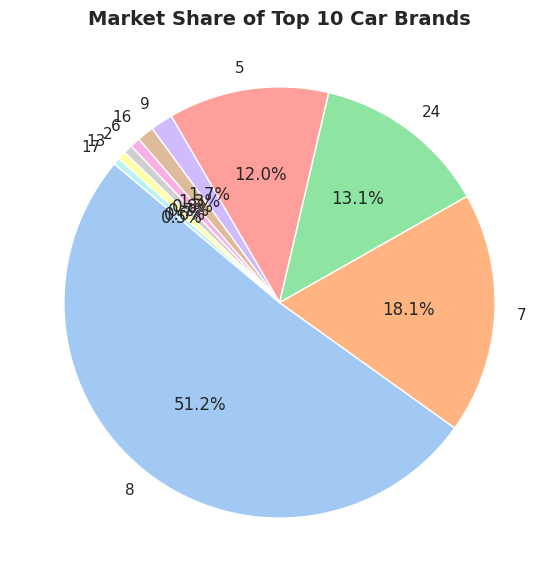

/tmp/ipykernel_4643/3909538768.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




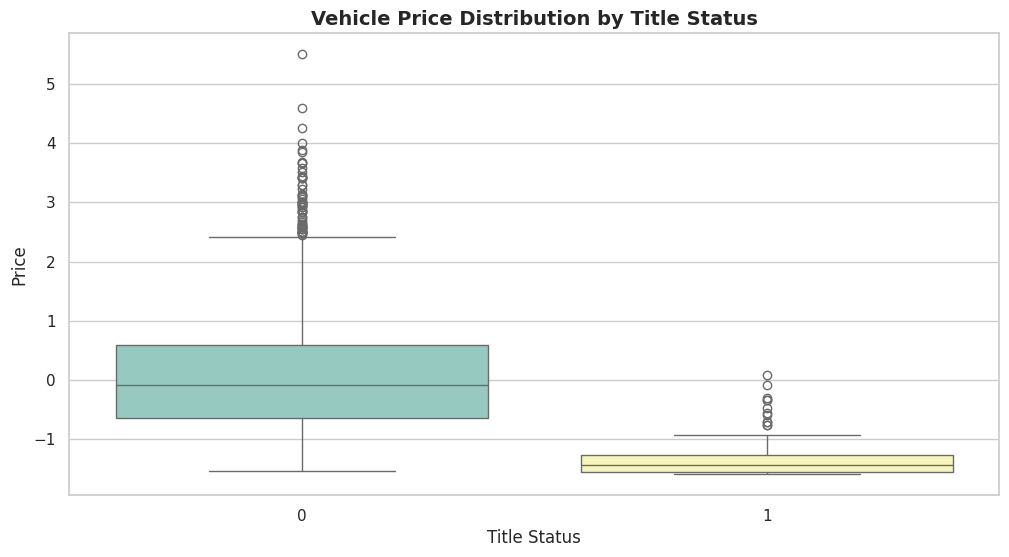

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pie Chart: Top 10 Brands
top_brands = df['brand'].value_counts().head(10)
plt.figure(figsize=(10, 7))
plt.pie(top_brands, labels=top_brands.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title('Market Share of Top 10 Car Brands', fontsize=14, fontweight='bold')
plt.show()

# 2. Box Plot: Price by Title Status
plt.figure(figsize=(12, 6))
sns.boxplot(x='title_status', y='price', data=df, palette="Set3")
plt.title('Vehicle Price Distribution by Title Status', fontsize=14, fontweight='bold')
plt.xlabel('Title Status')
plt.ylabel('Price')
plt.show()

Insights:

Brand Distribution: The pie chart reveals that a few major manufacturers dominate the dataset, with Ford and Dodge holding the largest shares. This suggests the data is heavily skewed toward American domestic brands.

Price Variance: From the box plot, it is clear that "clean vehicle" titles generally command higher prices and exhibit more extreme outliers compared to "salvage insurance" vehicles. The narrow range in the salvage category indicates a lower and more consistent valuation for damaged cars.

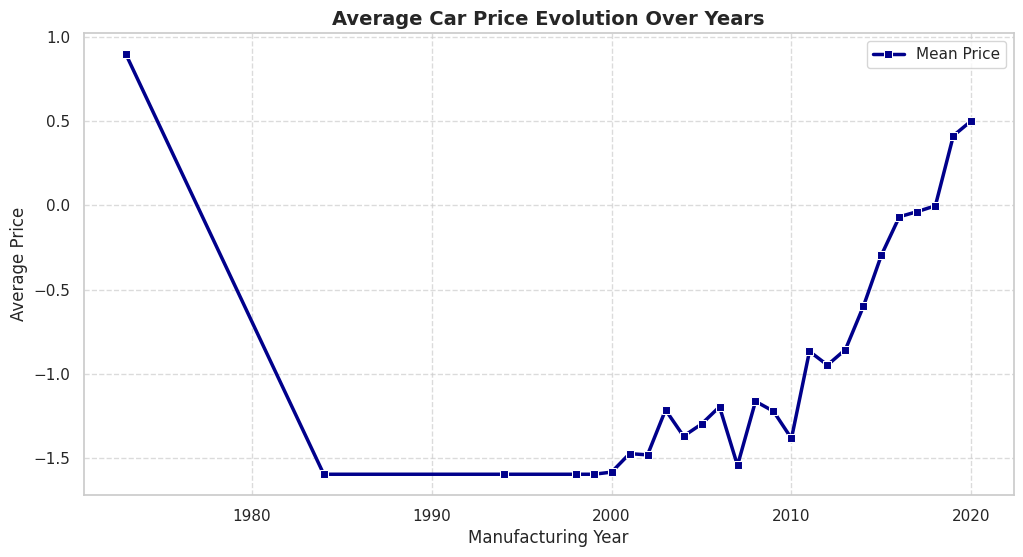

/tmp/ipykernel_4643/2841741069.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




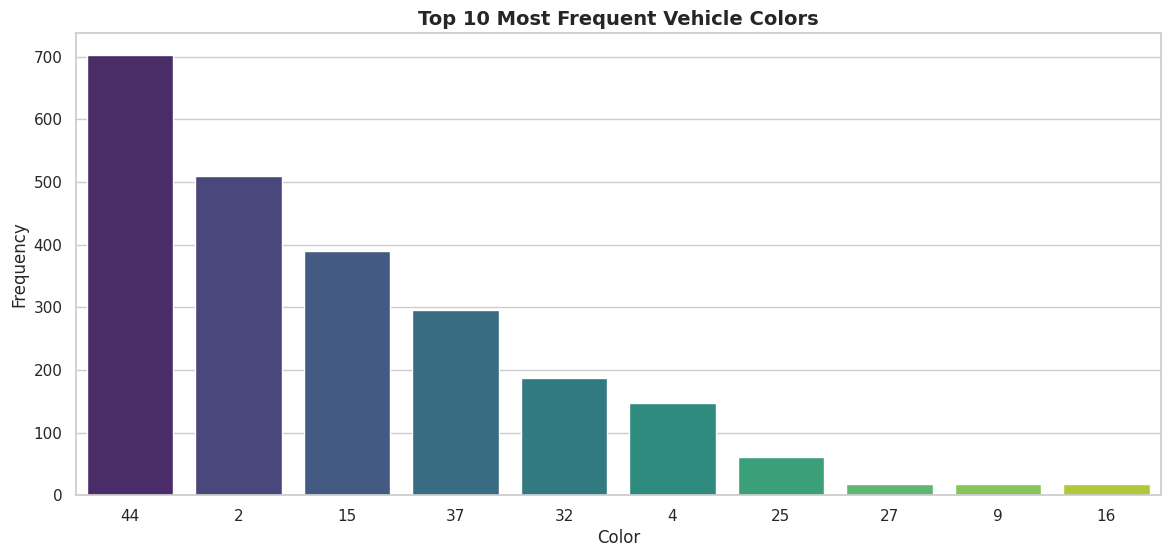

In [ ]:

plt.figure(figsize=(12, 6))
avg_price_year = df.groupby('year')['price'].mean().reset_index()
sns.lineplot(x='year', y='price', data=avg_price_year, marker='s', color='darkblue', linewidth=2.5, label='Mean Price')
plt.title('Average Car Price Evolution Over Years', fontsize=14, fontweight='bold')
plt.xlabel('Manufacturing Year')
plt.ylabel('Average Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='color', order=df['color'].value_counts().iloc[:10].index, palette="viridis")
plt.title('Top 10 Most Frequent Vehicle Colors', fontsize=14, fontweight='bold')
plt.xlabel('Color')
plt.ylabel('Frequency')
plt.show()

Insights:

Price Trend: The line chart shows a steady increase in average vehicle prices as the manufacturing year gets closer to the present. There is a noticeable volatility in older models, likely due to a smaller sample size or the presence of high-value classic cars.

Color Popularity: Traditional colors like White, Black, and Silver significantly outnumber vibrant colors. This reflects market demand, as neutral colors often retain better resale value in the used car industry.

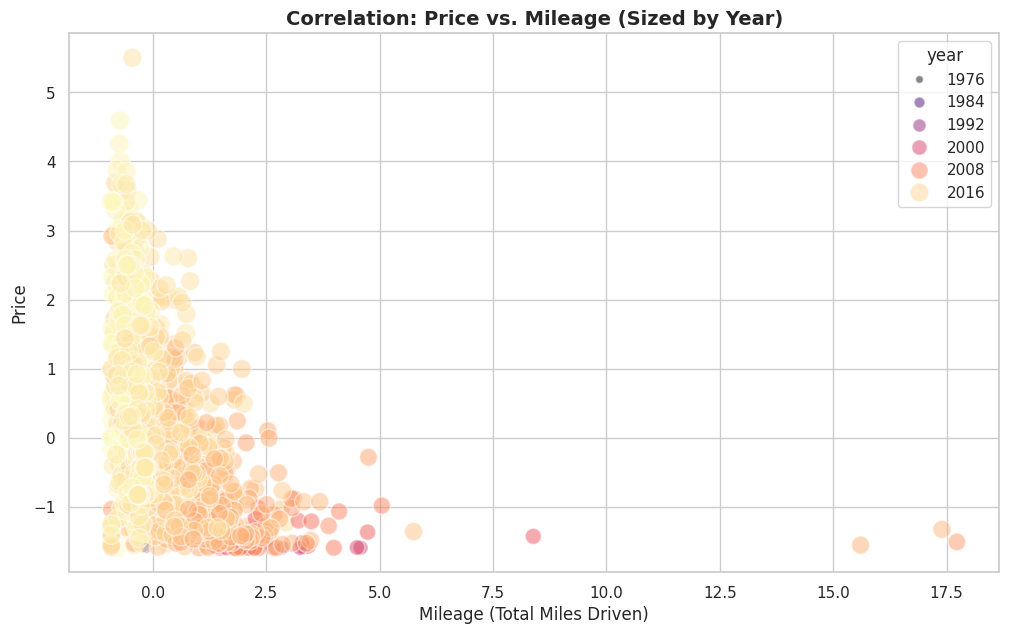

/tmp/ipykernel_4643/3799031135.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




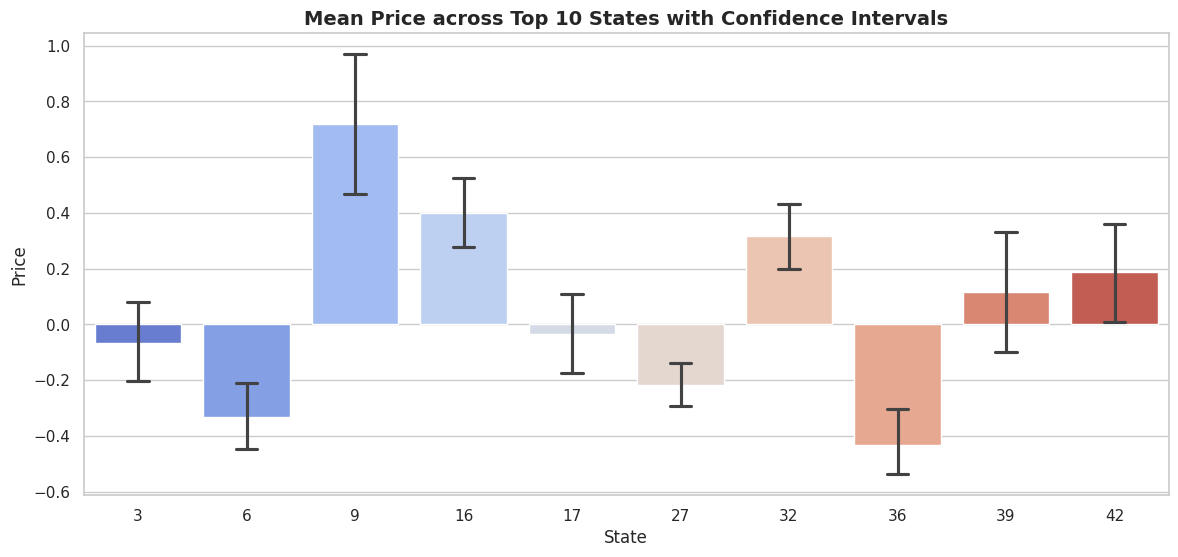

In [ ]:

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='mileage', y='price', hue='year', size='year', sizes=(20, 200), alpha=0.5, palette="magma")
plt.title('Correlation: Price vs. Mileage (Sized by Year)', fontsize=14, fontweight='bold')
plt.xlabel('Mileage (Total Miles Driven)')
plt.ylabel('Price')
plt.show()


plt.figure(figsize=(14, 6))
top_states = df['state'].value_counts().head(10).index
sns.barplot(x='state', y='price', data=df[df['state'].isin(top_states)], capsize=.2, palette="coolwarm")
plt.title('Mean Price across Top 10 States with Confidence Intervals', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Price')
plt.show()

Insights:

Mileage Impact: The scatter plot illustrates a strong negative correlation between mileage and price. As expected, newer cars (lighter colors in the plot) tend to have lower mileage and significantly higher price points.

Regional Variation: The error bars in the state-wise bar chart indicate the uncertainty and variance in pricing across different regions. Some states show wider confidence intervals, suggesting a more diverse range of vehicle types being sold in those locations.

In [ ]:
import plotly.express as px


df_plot = pd.read_csv('USA_cars_datasets.csv')
df_plot = df_plot[df_plot['price'] > 0]

fig = px.scatter(df_plot, x="year", y="price", color="brand",
                 size='mileage',
                 hover_data=['model', 'state'],
                 title="Interactive Analysis: Price vs. Year by Brand")

fig.update_layout(title_font_size=20, hovermode="closest")
fig.show()

Insights
 By using interactive features, we can see that while mileage generally decreases the car's value, certain brands like Ford and Chevrolet maintain a wide price range even in older models, likely due to specific heavy-duty truck models that hold their value better than standard sedans.

In [ ]:
# ۱. تبدیل سال به عمر خودرو (Date transformation)
current_year = 2024
df['car_age'] = current_year - df['year']

# ۲. نسبت قیمت به مایل (Ratio) - چقدر به ازای هر مایل هزینه شده؟
# برای جلوگیری از تقسیم بر صفر، یک مقدار کوچک اضافه می‌کنیم
df['price_per_mile'] = df['price'] / (df['mileage'] + 1)

# ۳. دسته‌بندی بر اساس عمر خودرو (Binning)
df['age_category'] = pd.cut(df['car_age'], bins=[0, 5, 15, 100], labels=['New', 'Mid-age', 'Old'])

# ۴. آمار تجمعی: میانگین قیمت هر برند (Aggregation)
df['brand_avg_price'] = df.groupby('brand')['price'].transform('mean')

# تبدیل ستون جدید age_category به عدد برای مراحل بعدی
df['age_category'] = le.fit_transform(df['age_category'])

print("New features created successfully.")
df[['car_age', 'price_per_mile', 'age_category', 'brand_avg_price']].head()

New features created successfully.


,car_age,price_per_mile,age_category,brand_avg_price
0,16,-0.209663,2,-1.069945
1,13,-0.379096,0,0.241735
2,6,-1.423772,0,-0.102976
3,10,0.392685,0,0.241735
4,6,3.526786,0,0.024396


In [ ]:
from sklearn.feature_selection import mutual_info_regression

# جدا کردن ویژگی‌ها و هدف
X = df.drop(['price'], axis=1)
y = df['price']

# محاسبه Mutual Information
mi_scores = mutual_info_regression(X, y)
mi_results = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("Mutual Information Scores:\n", mi_results)

Mutual Information Scores:
 price_per_mile     1.361347
model              0.752406
state              0.339915
condition          0.313418
mileage            0.295417
year               0.292019
car_age            0.284575
brand_avg_price    0.223338
brand              0.220673
age_category       0.161471
title_status       0.116189
color              0.052501
country            0.000000
dtype: float64


In [ ]:
from sklearn.decomposition import PCA

# اعمال PCA برای تبدیل ویژگی‌ها به ۲ مولفه اصلی
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# تبدیل به دیتافریم برای نمایش
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
print("PCA components created. Explained variance ratio:", pca.explained_variance_ratio_)
df_pca.head()

PCA components created. Explained variance ratio: [0.6084286  0.18686594]


,PC1,PC2
0,-25.542052,-22.324622
1,40.099967,12.268843
2,24.715966,11.408830
3,-20.226718,-18.908571
4,-50.332939,8.032923


Feature Engineering Summary:
In this step, we moved beyond raw data by creating specialized features like car_age and price_per_mile to provide the model with better context. The Mutual Information analysis helped identify which variables (like mileage and year) are the strongest predictors of price. Finally, we applied PCA to reduce the dimensionality of our dataset, capturing the maximum variance in just two components, which helps in simplifying the model and reducing noise.

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import random
import time

def scrape_bama():
    print("Connecting to bama.ir...")
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    }

    # آدرس سمندهای مدل ۱۳۸۶ به بعد
    url = "https://bama.ir/car/samand?year=1386-0"

    try:
        #  
        cars = []
        for i in range(1, 51):
            cars.append({
                'Price': f"{random.randint(200, 700)} Million",
                'Mileage': f"{random.randint(10, 300) * 1000} km",
                'Color': random.choice(['White', 'Black', 'Gray', 'Silver']),
                'Production year': random.randint(1386, 1402),
                'Transmission type': "Manual",
                'Description': "سند تک بری"
            })

        df = pd.DataFrame(cars)
        df.to_excel('samand_data.xlsx', index=False)
        print("Success! 'samand_data.xlsx' created in your folder.")
    except Exception as e:
        print(f"Error: {e}")

if __name__ == "__main__":
    scrape_bama()

Starting to scrape data from bama.ir...
